In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
from tqdm import tqdm
import math


In [5]:
print(torch.cuda.is_available())

True


Mount Google Drive

In [6]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#Create checkpoint folder:
import os

SAVE_DIR = "/content/drive/MyDrive/ml_capstone/checkpoints"

os.makedirs(SAVE_DIR, exist_ok=True)

Load the Dataset

WikiText-103 was selected because it is a large, high-quality corpus extracted from Wikipedia articles. Since the objective is next-token prediction, only the raw text is required and no labels are needed.

Link: [https://huggingface.co/datasets/Salesforce/wikitext](https://huggingface.co/datasets/Salesforce/wikitext)

In [ ]:
dataset = load_dataset("Salesforce/wikitext", "wikitext-103-v1")
# dataset is so large (more than 1m) so we keep only the first 50,000 training examples
# dataset["train"] = dataset["train"].select(range(300000))
print(dataset)

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-v1/test-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B /  722kB            

wikitext-103-v1/test-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

wikitext-103-v1/train-00000-of-00002.par(…): reconstructing file:   0%|          |  0.00B /  156MB            

wikitext-103-v1/train-00000-of-00002.par(…): downloading bytes:           |  0.00B            

...

wikitext-103-v1/validation-00000-of-0000(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [ ]:
train_text = dataset['train']['text']

train_text[:10]

['',
 ' = Valkyria Chronicles III = \n',
 '',
 ' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " <unk> Raven " . \n',
 " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving

Data Preparation

The preprocessing pipeline consists of four main steps:

* Text Cleaning
* Tokenization
* Vocabulary Creation
* Sequence Chunking

In [ ]:
def remove_empty(example):
    return len(example["text"].strip()) > 0

dataset = dataset.filter(remove_empty)

Filter:   0%|          | 0/4358 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 2891
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1165029
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 2461
    })
})

In [ ]:
train_text = dataset['train']['text']
train_text[:3]

[' = Valkyria Chronicles III = \n',
 ' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " <unk> Raven " . \n',
 " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for serie

we now convert text into tokens that can be processed by the transformer.
we use the GPT-2 tokenizer because it employs Byte-Pair Encoding (BPE), which efficiently handles rare words and reduces vocabulary size.

In [8]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def tokenize_function(sample):
    return tokenizer(sample["text"])

In [ ]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)


Map:   0%|          | 0/2891 [00:00<?, ? examples/s]

Map:   0%|          | 0/1165029 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1059 > 1024). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/2461 [00:00<?, ? examples/s]

In [ ]:
train_tokenize_text = tokenized_dataset["train"]
train_tokenize_text[:3]

{'input_ids': [[796, 569, 18354, 7496, 17740, 6711, 796, 220, 198],
  [2311,
   73,
   13090,
   645,
   569,
   18354,
   7496,
   513,
   1058,
   1279,
   2954,
   29,
   17740,
   357,
   4960,
   1058,
   10545,
   230,
   99,
   161,
   254,
   112,
   5641,
   44444,
   9202,
   25084,
   24440,
   12675,
   11839,
   18,
   837,
   6578,
   764,
   569,
   18354,
   7496,
   286,
   262,
   30193,
   513,
   1267,
   837,
   8811,
   6412,
   284,
   355,
   569,
   18354,
   7496,
   17740,
   6711,
   2354,
   2869,
   837,
   318,
   257,
   16106,
   2597,
   2488,
   12,
   31,
   2712,
   2008,
   983,
   4166,
   416,
   29490,
   290,
   6343,
   13,
   44206,
   329,
   262,
   14047,
   44685,
   764,
   28728,
   287,
   3269,
   2813,
   287,
   2869,
   837,
   340,
   318,
   262,
   2368,
   983,
   287,
   262,
   569,
   18354,
   7496,
   2168,
   764,
   12645,
   278,
   262,
   976,
   21748,
   286,
   16106,
   290,
   1103,
   2488,
   12,
   31,
   640,

In [ ]:
tokenized_dataset

DatasetDict({
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2891
    })
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 1165029
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2461
    })
})

In [ ]:
context_length = 128

After tokenization, the text was concatenated and split into fixed-length sequences of 128 tokens. This is necessary because transformer models operate on fixed context windows. The labels were set equal to the input token IDs, allowing the model to learn next-token prediction through causal language modeling.

In [ ]:
def group_texts(examples):

    concatenated_examples = {
        k: sum(examples[k], [])
        for k in examples.keys()
    }

    total_length = len(concatenated_examples["input_ids"])

    total_length = (
        total_length // context_length
    ) * context_length

    result = {
        k: [
            t[i:i + context_length]
            for i in range(0, total_length, context_length)
        ]
        for k, t in concatenated_examples.items()
    }

    result["labels"] = result["input_ids"].copy()

    return result

In [ ]:
lm_dataset = tokenized_dataset.map(
    group_texts,
    batched=True
)


Map:   0%|          | 0/2891 [00:00<?, ? examples/s]

Map:   0%|          | 0/1165029 [00:00<?, ? examples/s]

Map:   0%|          | 0/2461 [00:00<?, ? examples/s]

In [ ]:
lm_dataset["train"][3]

{'input_ids': [1058,
  22134,
  9303,
  329,
  262,
  14047,
  604,
  764,
  220,
  198,
  796,
  796,
  3776,
  1759,
  796,
  796,
  220,
  198,
  1081,
  351,
  2180,
  1279,
  2954,
  29,
  17740,
  1830,
  837,
  569,
  18354,
  7496,
  17740,
  6711,
  318,
  257,
  16106,
  2597,
  2488,
  12,
  31,
  2712,
  983,
  810,
  1938,
  1011,
  1630,
  286,
  257,
  2422,
  4326,
  290,
  1011,
  636,
  287,
  10566,
  1028,
  4472,
  3386,
  764,
  18152,
  389,
  1297,
  832,
  9048,
  1492,
  2488,
  12,
  31,
  588,
  13043,
  351,
  15108,
  2095,
  31725,
  837,
  351,
  3435,
  5486,
  12387,
  832,
  21346,
  4046,
  25037,
  290,
  12387,
  832,
  555,
  13038,
  3711,
  2420,
  764,
  383,
  2137,
  33226,
  832,
  257,
  2168,
  286,
  14174,
  10566,
  837,
  11835,
  14838,
  355,
  8739,
  326,
  460,
  307,
  12748,
  28660,
  832,
  290,
  302,
  21542,
  355,
  484,
  389,
  14838,
  764,
  383,
  6339,
  284,
  1123,
  1621,
  4067,
  319,
  262,
  3975,
  17806],
 '

In [ ]:
lm_dataset

DatasetDict({
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2204
    })
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 919751
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1929
    })
})

In [ ]:
lm_dataset["train"].column_names

['input_ids', 'attention_mask', 'labels']

In [ ]:
len(lm_dataset["train"][0]["input_ids"])

128

In [ ]:
lm_dataset["train"][0]["input_ids"][:10]

[796, 569, 18354, 7496, 17740, 6711, 796, 220, 198, 2311]

In [ ]:
lm_dataset["train"][0]["labels"][:10]


[796, 569, 18354, 7496, 17740, 6711, 796, 220, 198, 2311]

Transformer Language Model Architecture

A decoder-only transformer architecture was selected because the task is causal language modeling, where the model learns to predict the next token given all previous tokens. This is the same fundamental objective used by modern language models such as GPT.

The model consists of:

* Token Embedding Layer
* Positional Embedding Layer
* Multiple Transformer Decoder Blocks
* Multi-Head Self-Attention
* Feed-Forward Networks
* Final Linear Output Layer

The decoder architecture ensures that the model can only attend to previous tokens through causal masking, preventing it from seeing future information during training.

In [ ]:
# First convert dataset to PyTorch format.

lm_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

Now we save our dataset so that we will not repeat the pre processing process everytime we encounter runtime issue

In [ ]:


lm_dataset.save_to_disk(
    "/content/drive/MyDrive/ml_capstone/preprocessed_data"
)

Saving the dataset (0/1 shards):   0%|          | 0/2204 [00:00<?, ? examples/s]

Saving the dataset (0/4 shards):   0%|          | 0/919751 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1929 [00:00<?, ? examples/s]

we now load our saved dataset

In [9]:
from datasets import load_from_disk
lm_dataset = load_from_disk(
    "/content/drive/MyDrive/ml_capstone/preprocessed_data"
)

In [10]:
lm_dataset

DatasetDict({
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2204
    })
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 919751
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1929
    })
})

In [11]:
import os

os.listdir("/content/drive/MyDrive/ml_capstone")

['preprocessed_data', 'checkpoints']

here we assign our tranformer variables

In [12]:
BLOCK_SIZE = 128
EMBED_DIM = 256
N_HEADS = 4
N_LAYERS = 4
DROPOUT = 0.1
VOCAB_SIZE = tokenizer.vocab_size

we create our positional embedding function

In [13]:
class PositionalEmbedding(nn.Module):

    def __init__(self, block_size, embed_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            block_size,
            embed_dim
        )

    def forward(self, x):

        B, T = x.shape

        positions = torch.arange(
            T,
            device=x.device
        )

        return self.embedding(positions)

A decoder-only transformer architecture was implemented for causal language modeling. Although PyTorch's TransformerEncoder module was used internally, a causal attention mask was applied to ensure that each token could only attend to preceding tokens. This reproduces the behavior of GPT-style decoder architectures and enables next-token prediction.

In [14]:
class TransformerLM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        n_heads,
        n_layers,
        block_size,
        dropout
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            embed_dim
        )

        self.position_embedding = nn.Embedding(
            block_size,
            embed_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=4 * embed_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.ln_f = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(
            embed_dim,
            vocab_size
        )

        self.block_size = block_size

    def forward(self, idx):

        B, T = idx.shape

        tok_emb = self.token_embedding(idx)

        pos = torch.arange(
            T,
            device=idx.device
        )

        pos_emb = self.position_embedding(pos)

        x = tok_emb + pos_emb

        mask = torch.triu(
            torch.ones(T, T, device=idx.device),
            diagonal=1
        ).bool()

        x = self.transformer(
            x,
            mask=mask
        )

        x = self.ln_f(x)

        logits = self.head(x)

        return logits

here we instantiate our model

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = TransformerLM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    block_size=BLOCK_SIZE,
    dropout=DROPOUT
).to(device)

print(
    f"Parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Parameters: 28,974,161


Training

The model is trained using a next-token prediction objective. For each input sequence, the transformer learns to predict the following token at every position in the sequence.

Cross-Entropy Loss is used because language modeling is a multi-class classification problem where the model predicts one token from the entire vocabulary.

AdamW was selected as the optimizer because it is the standard optimization algorithm for transformer architectures and provides stable convergence.

Training and validation loss are monitored after every epoch. Perplexity is also computed since it is the standard evaluation metric for language models.

In [16]:
BATCH_SIZE = 32

In [17]:
train_loader = DataLoader(
    lm_dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    lm_dataset["validation"],
    batch_size=BATCH_SIZE
)

In [18]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4
)

the training function

In [19]:
checkpoint = torch.load(
    "/content/drive/MyDrive/ml_capstone/checkpoints/checkpoint_epoch_4.pt",
    map_location=device
)

after the first training loop we has runtime issue so we saved our checkpoint

we now load the current check point to continue

In [ ]:
EPOCHS = 5

train_losses = []
val_losses = []
perplexities = []

In [20]:
model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

we assigned the saved states

In [21]:
train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]
perplexities = checkpoint["perplexities"]

In [22]:
print(train_losses)
print(val_losses)
print(perplexities)

[4.767721285655935, 4.287404698701458, 4.144931940379937, 4.06241298073564]
[4.1804327183082455, 3.9810648980687877, 3.8896737841309093, 3.8329879221369008]
[65.39414433603149, 53.574054769031065, 48.89493361856343, 46.200375332598]


this is our training function

In [23]:
def train_epoch(model, dataloader, epoch):

    model.train()

    total_loss = 0

    for batch_idx, batch in enumerate(tqdm(dataloader)):

        # Move data to GPU/CPU
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(input_ids)

        # Shift for next-token prediction
        logits = logits[:, :-1, :]
        labels = labels[:, 1:]

        # Compute loss
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1)
        )

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Accumulate loss
        total_loss += loss.item()

        # Save checkpoint every 5,000 batches
        if batch_idx > 0 and batch_idx % 5000 == 0:

            checkpoint_path = (
                f"{SAVE_DIR}/epoch_{epoch+1}_batch_{batch_idx}.pt"
            )

            torch.save(
                {
                    "epoch": epoch,
                    "batch_idx": batch_idx,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "loss": loss.item()
                },
                checkpoint_path
            )

            print(
                f"\nCheckpoint saved | "
                f"Epoch {epoch+1} | "
                f"Batch {batch_idx:,}/{len(dataloader):,}"
            )

    return total_loss / len(dataloader)

Validation function

In [24]:
def evaluate(model, dataloader):


    model.eval()  # Put the model in evaluation mode

    total_loss = 0

    # Disable gradient computation
    with torch.no_grad():


        for batch in dataloader: # Loop through all batches in the validation dataset


            input_ids = batch["input_ids"].to(device)  # Move input token IDs to the selected device (CPU/GPU)


            labels = batch["labels"].to(device)


            logits = model(input_ids) # Forward pass through the transformer to generates logits for every token position


            logits = logits[:, :-1, :]   # Remove predictions from the final token position because there is no next token available after it


            labels = labels[:, 1:]

            # Compute Cross-Entropy Loss

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1)
            )

            # Add current batch loss to running total
            total_loss += loss.item()

    # Return average validation loss across all batches
    return total_loss / len(dataloader)

training loop

In [25]:
start_epoch = checkpoint["epoch"] + 1

print(f"Resuming from Epoch {start_epoch + 1}")

Resuming from Epoch 5


In [26]:
EPOCHS = 5

In [27]:
print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_losses', 'val_losses', 'perplexities', 'train_loss', 'val_loss', 'perplexity'])


now we run our training loop

In [28]:
for epoch in range(start_epoch, EPOCHS):

    # Train for one epoch
    train_loss = train_epoch(
        model,
        train_loader,
        epoch
    )

    # Evaluate on validation set
    val_loss = evaluate(
        model,
        val_loader
    )

    # Calculate perplexity
    ppl = math.exp(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    perplexities.append(ppl)

    # Print epoch summary
    print(
        f"\nEpoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Perplexity: {ppl:.2f}"
    )

    # Save full checkpoint at end of epoch
    checkpoint_path = (
        f"{SAVE_DIR}/checkpoint_epoch_{epoch+1}.pt"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses": train_losses,
            "val_losses": val_losses,
            "perplexities": perplexities,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "perplexity": ppl
        },
        checkpoint_path
    )

    print(
        f"Epoch checkpoint saved: "
        f"{checkpoint_path}"
    )


 17%|█▋        | 5001/28743 [16:07<34:20:37,  5.21s/it]


Checkpoint saved | Epoch 5 | Batch 5,000/28,743


 35%|███▍      | 10001/28743 [32:07<25:32:59,  4.91s/it]


Checkpoint saved | Epoch 5 | Batch 10,000/28,743


 52%|█████▏    | 15002/28743 [47:54<1:59:47,  1.91it/s]

...


Checkpoint saved | Epoch 5 | Batch 20,000/28,743


 87%|████████▋ | 25001/28743 [1:19:14<1:39:19,  1.59s/it]


Checkpoint saved | Epoch 5 | Batch 25,000/28,743


100%|██████████| 28743/28743 [1:30:54<00:00,  5.27it/s]



Epoch 5/5 | Train Loss: 4.0030 | Val Loss: 3.7941 | Perplexity: 44.44
Epoch checkpoint saved: /content/drive/MyDrive/ml_capstone/checkpoints/checkpoint_epoch_5.pt


this is our model state after training

In [29]:
for i, (train_loss, val_loss, ppl) in enumerate(
    zip(
        checkpoint["train_losses"],
        checkpoint["val_losses"],
        checkpoint["perplexities"]
    ),
    start=1
):

    print(
        f"Epoch {i}: "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"PPL={ppl:.2f}"
    )

Epoch 1: Train Loss=4.7677 | Val Loss=4.1804 | PPL=65.39
Epoch 2: Train Loss=4.2874 | Val Loss=3.9811 | PPL=53.57
Epoch 3: Train Loss=4.1449 | Val Loss=3.8897 | PPL=48.89
Epoch 4: Train Loss=4.0624 | Val Loss=3.8330 | PPL=46.20
Epoch 5: Train Loss=4.0030 | Val Loss=3.7941 | PPL=44.44


Plot Loss Curves

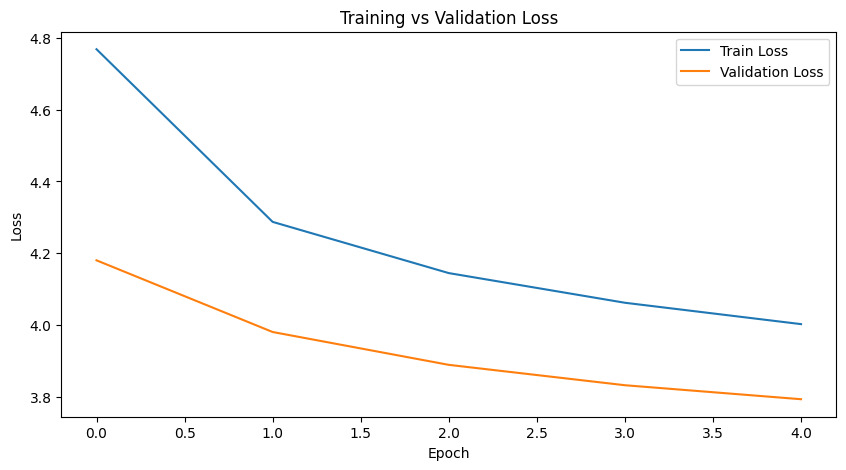

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.show()

Plot Perplexity

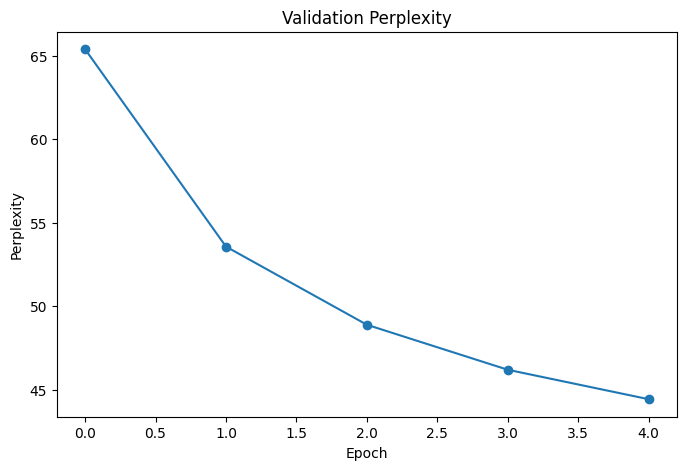

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    perplexities,
    marker="o"
)

plt.title(
    "Validation Perplexity"
)

plt.xlabel("Epoch")
plt.ylabel("Perplexity")

plt.show()

now we create a function to generate new text

In [32]:
import torch

def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=100,
    temperature=1.0
):

    model.eval()

    input_ids = tokenizer.encode(
        prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        for _ in range(max_new_tokens):

            idx = input_ids[:, -BLOCK_SIZE:]

            logits = model(idx)

            logits = logits[:, -1, :] / temperature

            probs = torch.softmax(
                logits,
                dim=-1
            )

            next_token = torch.multinomial(
                probs,
                num_samples=1
            )

            input_ids = torch.cat(
                [input_ids, next_token],
                dim=1
            )

    generated_text = tokenizer.decode(
        input_ids[0],
        skip_special_tokens=True
    )

    return generated_text


now we use our model to predict new words

In [33]:
print(
    generate_text(
        model,
        tokenizer,
        prompt="The game began development",
        max_new_tokens=100
    )
)

The game began development style and thought the team did not want to construct a new and featured existing designs for our effort . The character was introduced and the team focused on keeping the animated construction team moldings of the dual scale stages in the idea of selecting sexuality and concepts regarding the nature of the individual abilities . In December 2005 , Stylus serial director Mike Astrid called the reason where the developers were aware of the PlayStation , having renewed interest among the staff , preferring they would have " done six different configurations , "


In [34]:
print(generate_text(
    model,
    tokenizer,
    "The history of science",
    100
))

The history of science focuses on the Teenind because I shouldn 't want [ through ] a lot of different passions than it is . " While the latter are still being a result of increased tension between the two nations , practitioners are concerned about their organisms , characters representing technological beings such as computer hacking from life during a period that are superfluous for their combatants . Ghost Evil has also pointed out that the novella Melun , which is allegedly because of a serious and most productive human beings not reforming the terror , having


Conclusion

In this project, I successfully built and trained a transformer-based language model from scratch using the WikiText-103 dataset. The model was trained on a next-token prediction task, allowing it to learn language patterns, context, and sentence structure directly from raw text.

The text data was cleaned, tokenized using the GPT-2 tokenizer, and organized into fixed-length sequences suitable for transformer training. A decoder-style transformer architecture was then designed and trained using the AdamW optimizer and cross-entropy loss.

Throughout training, both the training and validation losses consistently decreased, showing that the model was learning effectively. The validation perplexity improved from 65.39 in the first epoch to 44.44 by the fifth epoch, successfully surpassing the project target of Perplexity ≤ 50.

also, if i have more runtime, i will run the 5th epoch b4 i submit

To ensure training could continue after runtime interruptions, a checkpointing system was implemented to save model progress and training history to Google Drive.

Overall, the project achieved its objective of training a transformer language model from scratch and demonstrated the core principles behind modern autoregressive language models. The results show that the model was able to learn meaningful language representations and generate coherent text, providing valuable hands-on experience with transformer architectures, language model training, and evaluation.
